In [1]:
from pathlib import Path
import runpy

BOOTSTRAP_CANDIDATES = (
    "notebooks/_bootstrap.py",
    "abstractgraph/notebooks/_bootstrap.py",
    "abstractgraph-ml/notebooks/_bootstrap.py",
    "abstractgraph-generative/notebooks/_bootstrap.py",
    "abstractgraph-graphicalizer/notebooks/_bootstrap.py",
)

_bootstrap_path = next(
    (
        candidate / relative
        for candidate in (Path.cwd(), *Path.cwd().parents)
        for relative in BOOTSTRAP_CANDIDATES
        if (candidate / relative).exists()
    ),
    None,
)
if _bootstrap_path is None:
    raise FileNotFoundError("Could not locate ecosystem notebooks/_bootstrap.py")

_bootstrap = runpy.run_path(str(_bootstrap_path))
repo_root = _bootstrap["repo_root"]
workspace_root = _bootstrap["workspace_root"]


In [2]:
%config InlineBackend.figure_format = 'retina'

import random
import time
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from sklearn.ensemble import RandomForestClassifier

from abstractgraph_graphicalizer.chem import draw_molecules as display_graphs

from abstractgraph.operators import *
from abstractgraph.hashing import hash_graph
from abstractgraph.graphs import graph_to_abstract_graph
from abstractgraph.vectorize import AbstractGraphTransformer
from abstractgraph_ml.estimators import GraphEstimator
from abstractgraph_generative.conditional import ConditionalAutoregressiveGenerator
from abstractgraph_generative.conditional_attributed import AttributedConditionalAutoregressiveGenerator
from abstractgraph_generative.conditional_batch import  ConditionalAutoregressiveGraphsGenerator
from abstractgraph_generative.edge_generator import (
    EdgeGenerator,
    edge_neighbors,
    make_edge_regression_dataset,
    remove_edges,
)


/Users/fabriziocosta/miniconda3/envs/py311/lib/python3.11/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.5.0) or chardet (7.2.0)/charset_normalizer (3.4.3) doesn't match a supported version!
  warnings.warn(


In [3]:
from abstractgraph_ml.feasibility import (
    FeasibilityEstimator,
    FeasibilityEstimatorFeatureCannotExist,
)

nbits = 19
feasibility_kwargs = dict(
    nbits=nbits,
    parallel=True,
    backend='loky',
    n_jobs=-1,
)

feasibility_estimators = [
    FeasibilityEstimatorFeatureCannotExist(
        decomposition_function=compose(neighborhood(radius=2), unlabel()),
        **feasibility_kwargs,
    ),
    FeasibilityEstimatorFeatureCannotExist(
        decomposition_function=path(number_of_edges=2),
        **feasibility_kwargs,
    ),
    FeasibilityEstimatorFeatureCannotExist(
        decomposition_function=neighborhood(radius=1),
        **feasibility_kwargs,
    ),
    FeasibilityEstimatorFeatureCannotExist(
        decomposition_function=cycle(),
        **feasibility_kwargs,
    ),
    FeasibilityEstimatorFeatureCannotExist(
        decomposition_function=compose(combination(number_of_elements=(2, 3), distance=0), cycle(), unlabel()),
        **feasibility_kwargs,
    ),
]

feasibility_estimator = FeasibilityEstimator(feasibility_estimators)

size: 528
max_num_nodes: 17
dataset size: 10


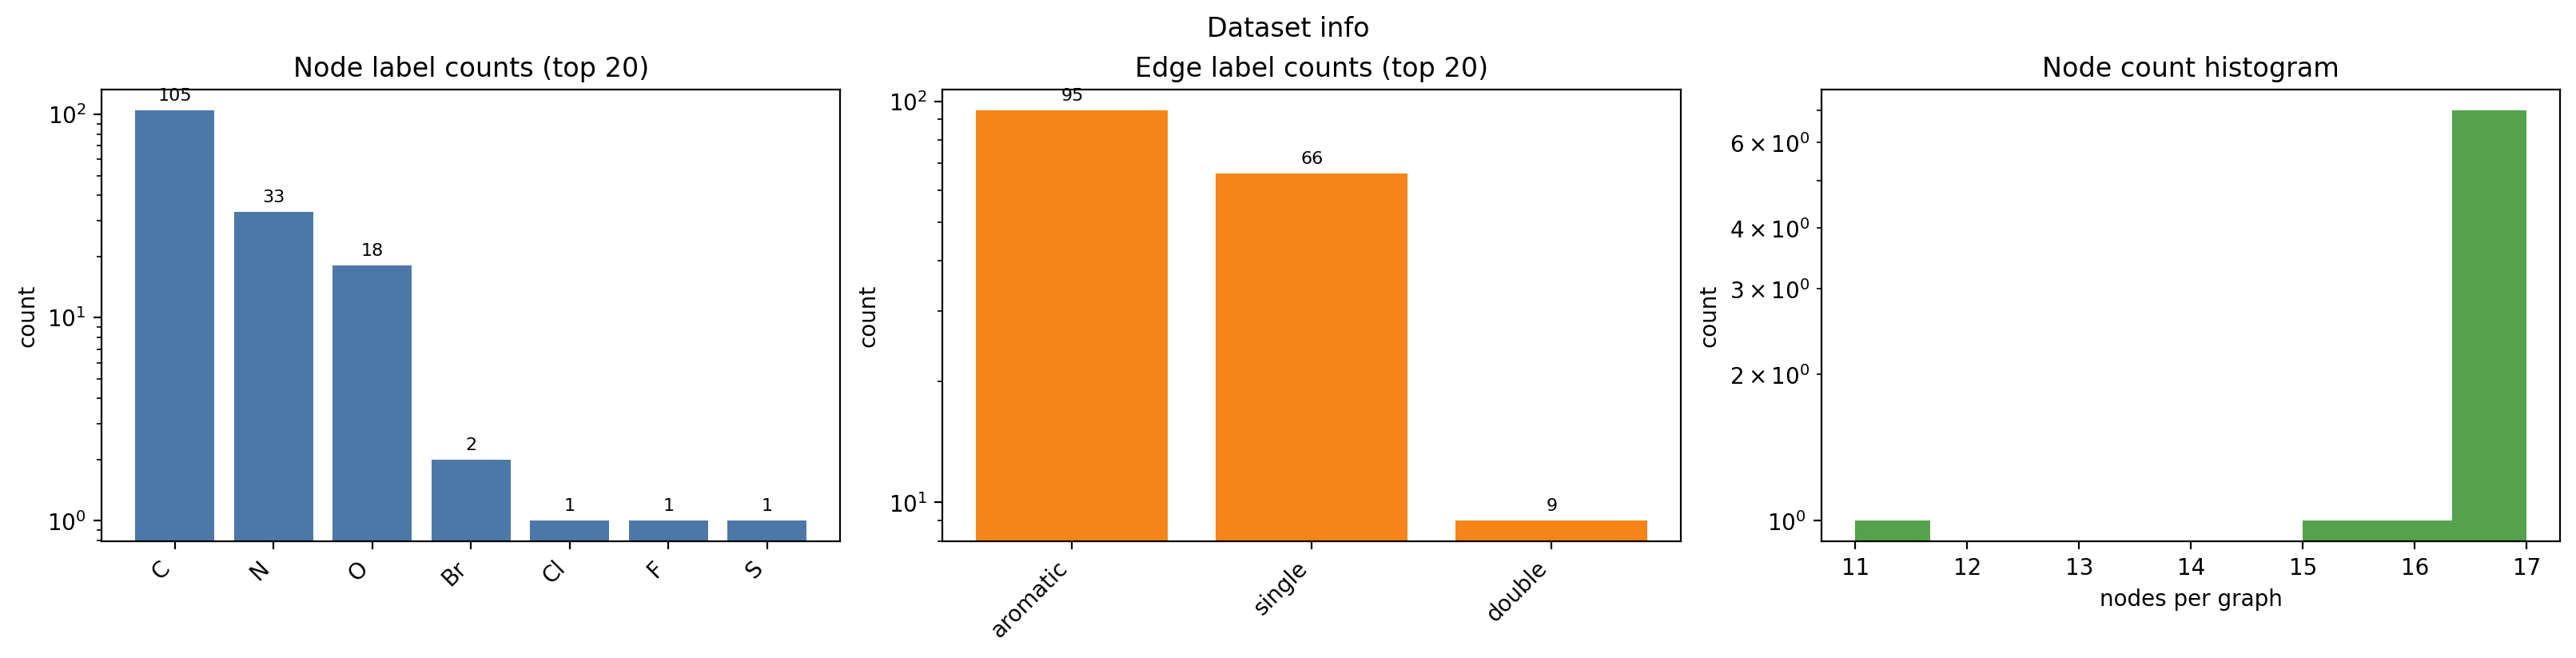

In [4]:
from abstractgraph_graphicalizer.chem import PubChemLoader

loader = PubChemLoader(on_error="skip")

assay_ids = ['2631','624249','651741','588350','463230','492952','743219','492992','463213']
assay_id = assay_ids[1]
assay_id = '624249' #bundled-safe assay example
size = 2000
max_num_nodes = 17
use_equalized = True


limit_active = int(size // 2) if use_equalized else int(size)
limit_inactive = int(size // 2) if use_equalized else int(size)
graphs, targets = loader.load(
    assay_id,
    limit_active=limit_active,
    limit_inactive=limit_inactive,
)
targets = np.array(targets)
print(f"size: {len(graphs)}")

keep = [i for i, graph in enumerate(graphs) if graph.number_of_nodes() <= max_num_nodes]
graphs = [graphs[i] for i in keep]
targets = targets[keep]

print(f"max_num_nodes: {max_num_nodes}")

from abstractgraph.utils import plot_graph_label_counts
_ = plot_graph_label_counts(graphs, top=20, title='Dataset info', log_scale=True)

# Keep downstream notebook cells unchanged
all_graphs = graphs
all_targets = targets
print('dataset size:', len(all_graphs))


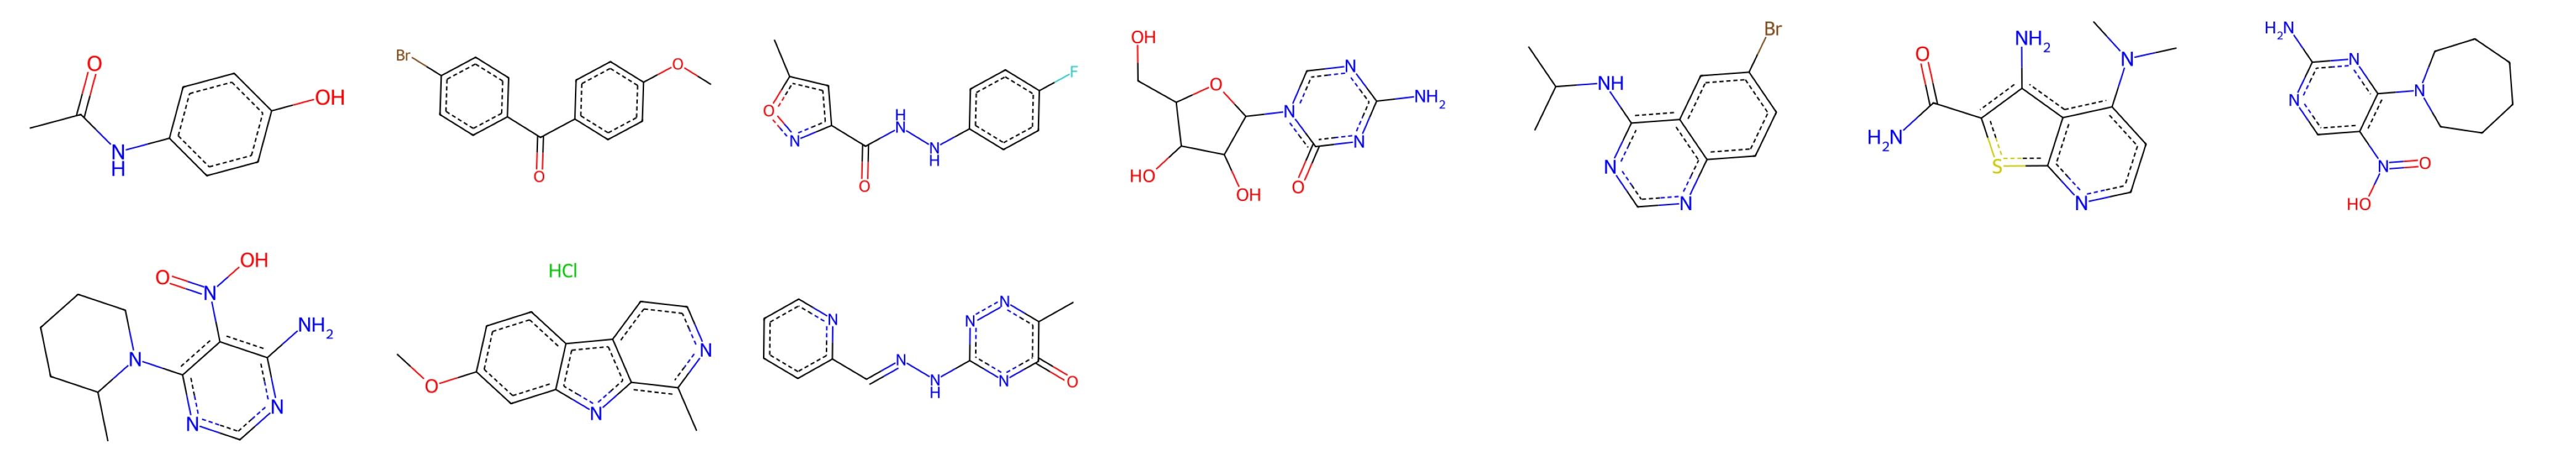

In [5]:
_ = display_graphs(graphs[:7*2], n_graphs_per_line=7)

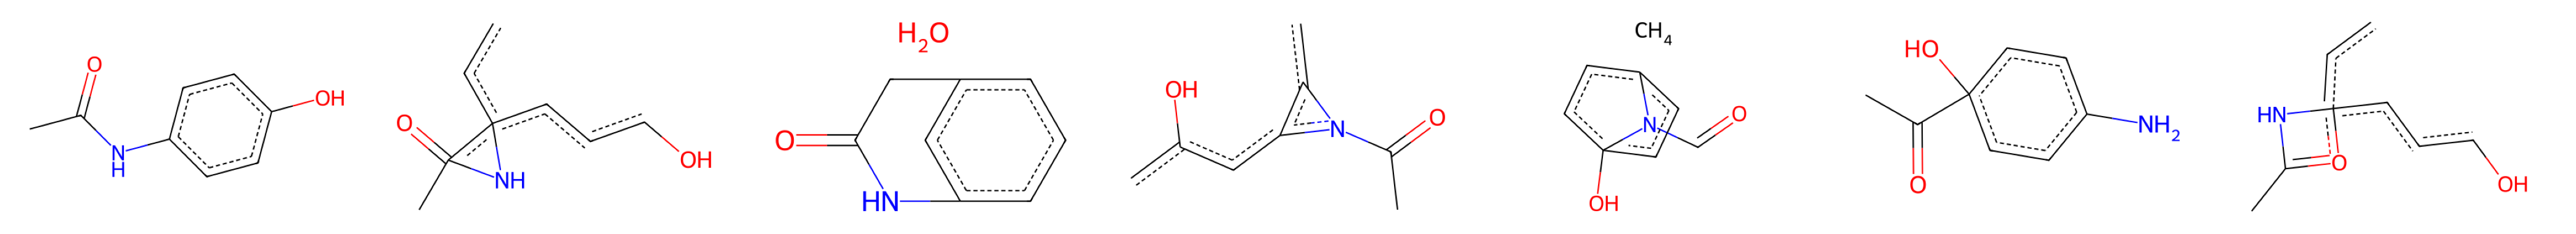

In [6]:
graph= graphs[0]
perturbed_graphs = edge_neighbors(graph, n_samples=6)
_ = display_graphs([graph]+perturbed_graphs, n_graphs_per_line=7)

In [7]:

n_negative_per_positive = 3
positives, negatives, dataset = make_edge_regression_dataset(
    graph,
    n_negative_per_positive=n_negative_per_positive,
    seed=0,
)

print('n_positives =', len(positives))
print('n_negatives =', len(negatives))
print('dataset_size =', len(dataset))
print('n_terminal_positives =', sum(G.number_of_edges() == 0 for G in positives))

n_positives = 11
n_negatives = 30
dataset_size = 41
n_terminal_positives = 1


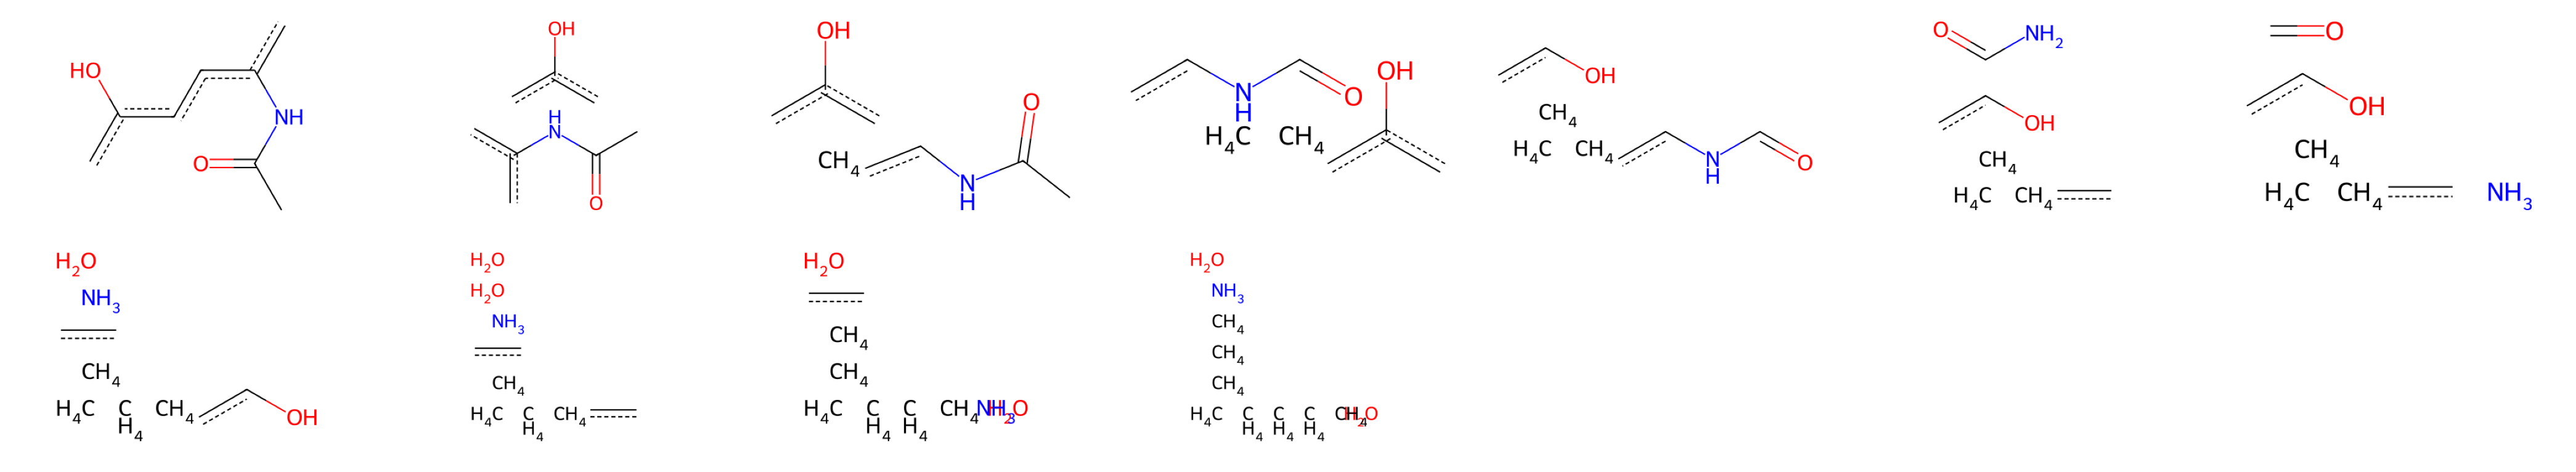

In [8]:
_ = display_graphs(positives[:7*2], n_graphs_per_line=7)

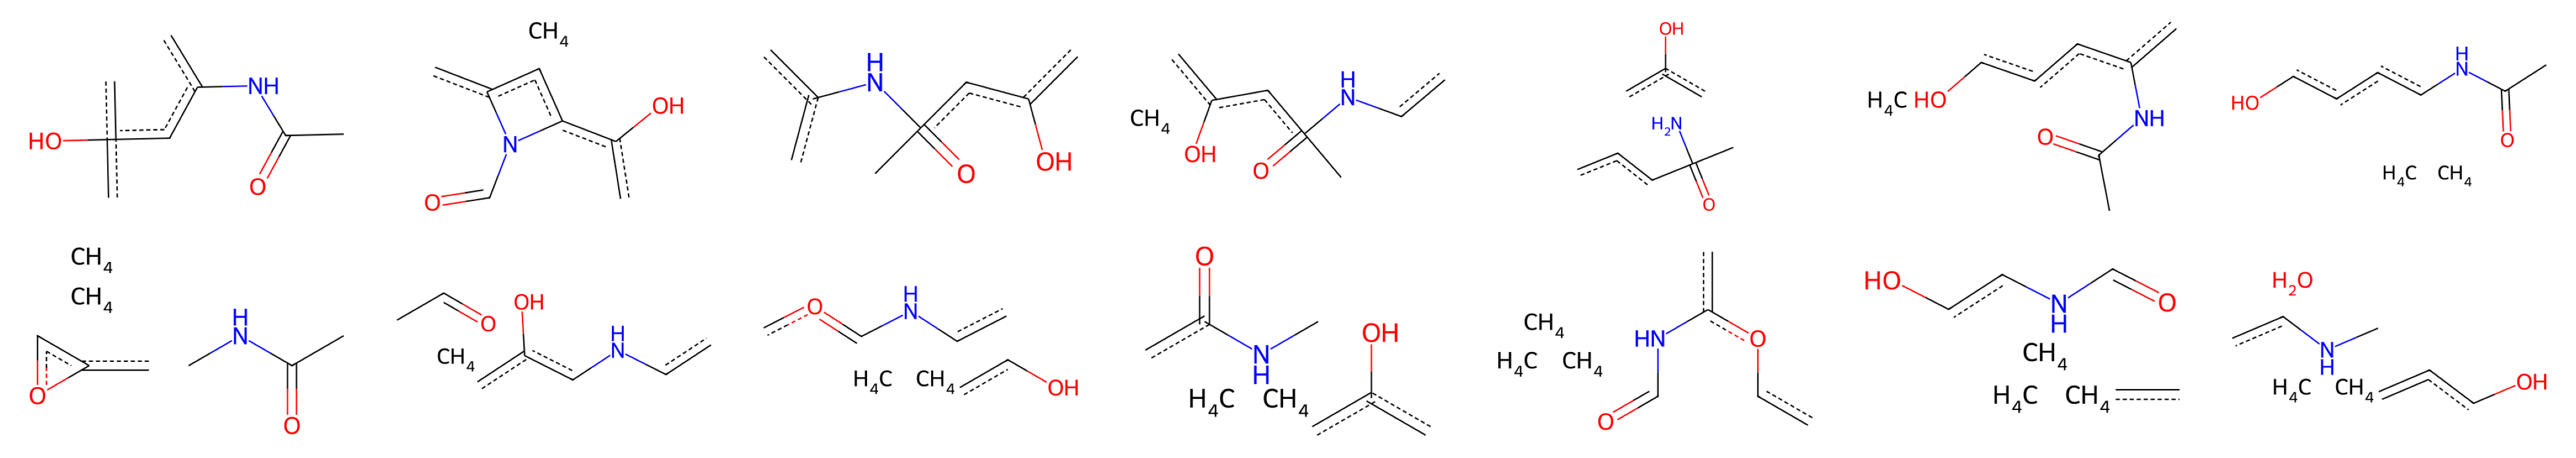

In [9]:
_ = display_graphs(negatives[:7*2], n_graphs_per_line=7)

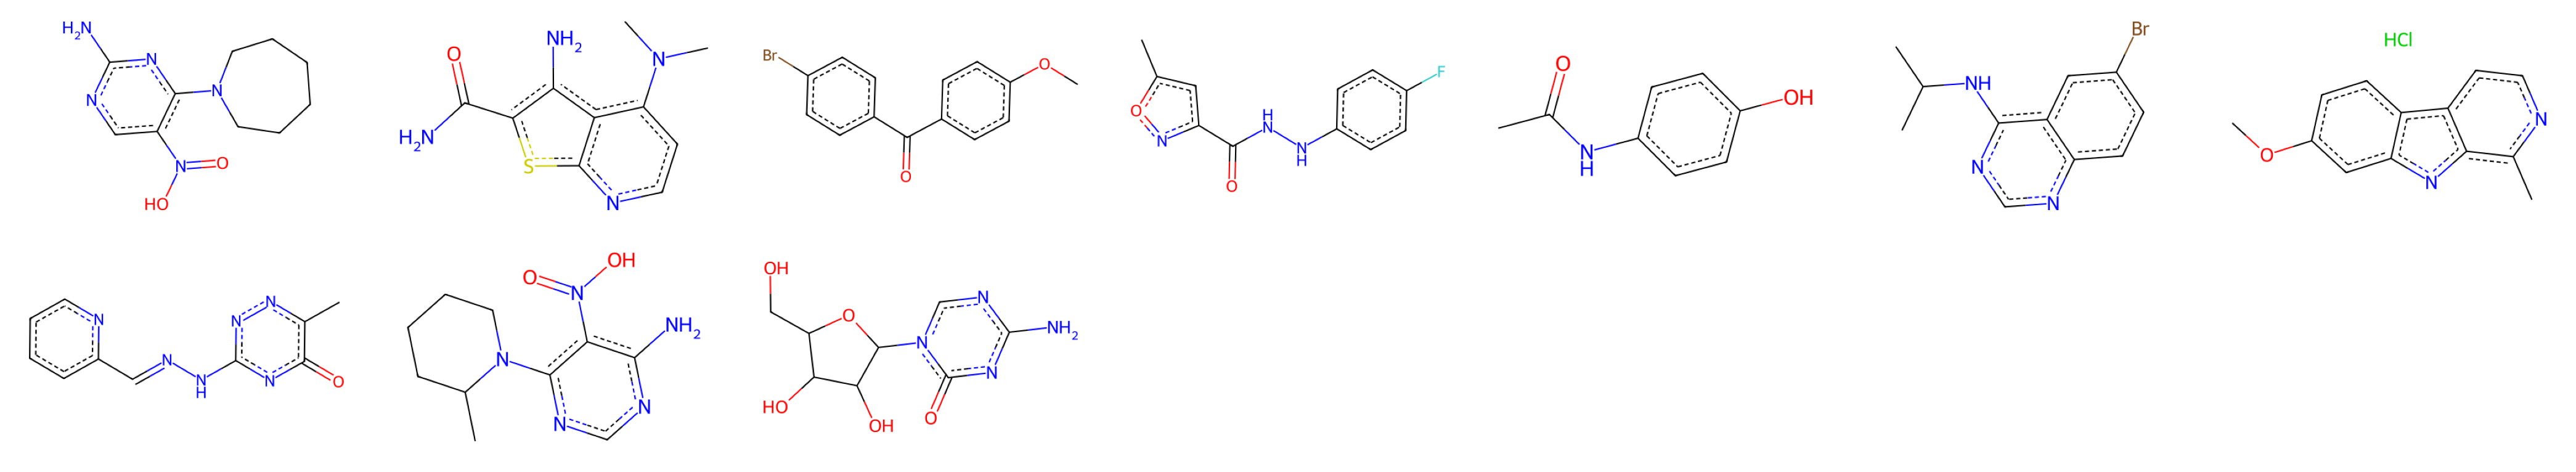

In [11]:
fit_graphs = random.sample(graphs, k=min(10, len(graphs)))
_ = display_graphs(fit_graphs, n_graphs_per_line=7)

In [ ]:
%%time
df = add(neighborhood(radius=(1,2)), path(number_of_edges=2))
transformer = AbstractGraphTransformer(
    nbits=14,
    decomposition_function=df,
    return_dense=True,
    n_jobs=-1,
)
graph_estimator = GraphEstimator(
    transformer=transformer,
    estimator=RandomForestClassifier(random_state=0, n_estimators=300, n_jobs=-1, class_weight="balanced_subsample",),
)

generator = EdgeGenerator(
    feasibility_estimator,
    graph_estimator,
    n_negative_per_positive=5,
    n_replicates=10,
    beam_size=2,
    fit_n_jobs=-1,
    fit_backend='loky',
    verbose=True,
    seed=0,
).fit(fit_graphs)


[fit] feasibility_graphs=1600 positives=1700 negatives=8000 dataset=9700 time=1m 27.1s


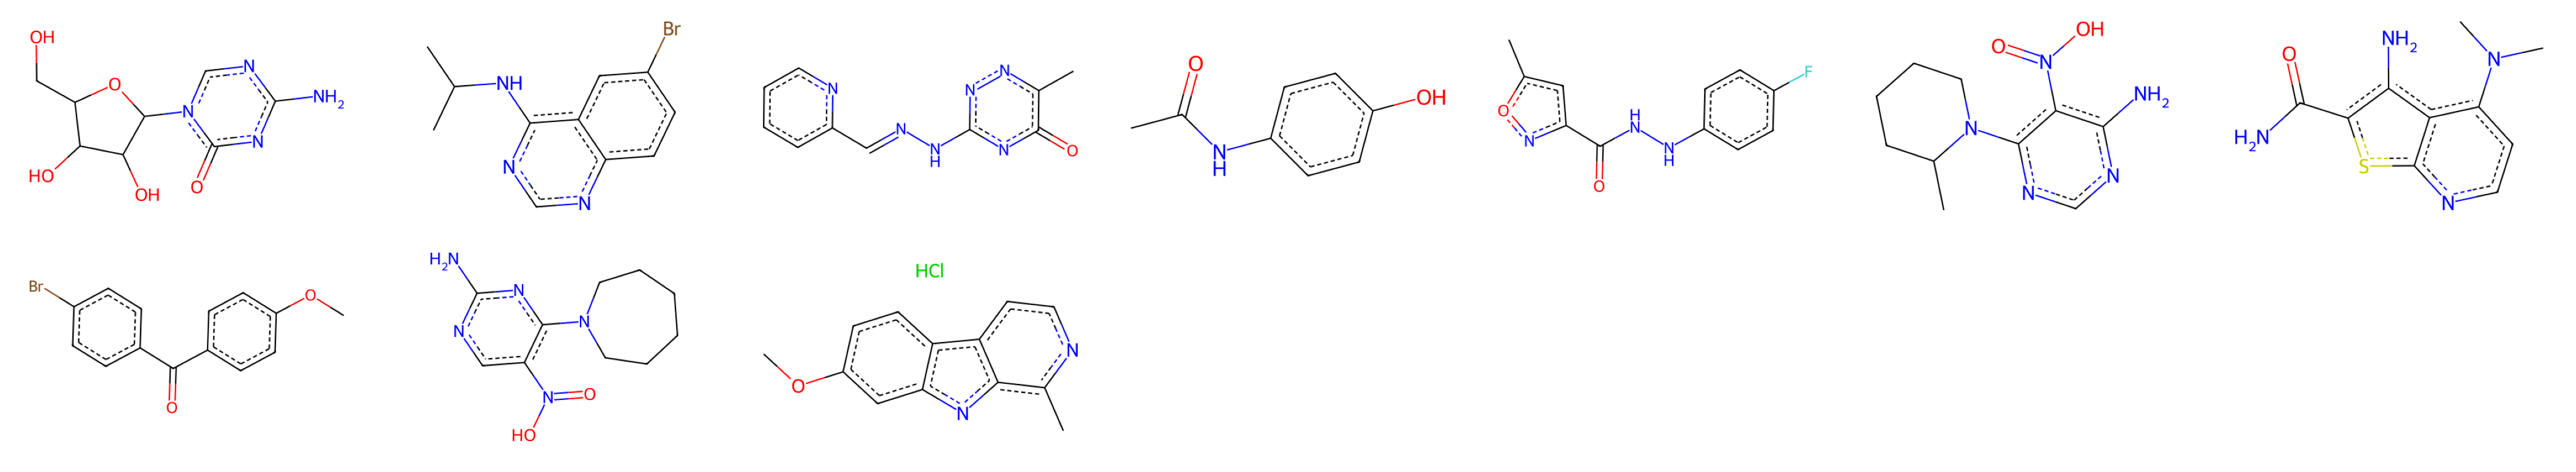

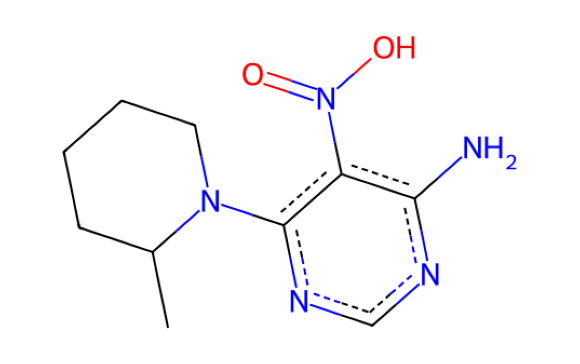

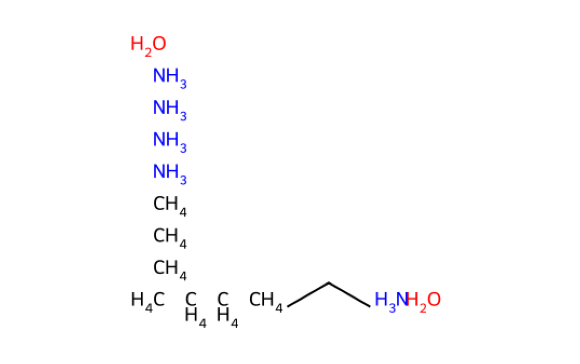

[fit] feasibility_graphs=1600 positives=1700 negatives=8000 dataset=9700 time=1m 11.1s
[fit] graph_estimator_graphs=9700 positive_labels=1700 negative_labels=8000 time=19m 46.9s
[graph 0] start start_edges=2 target_edges=18 remaining_edges=16


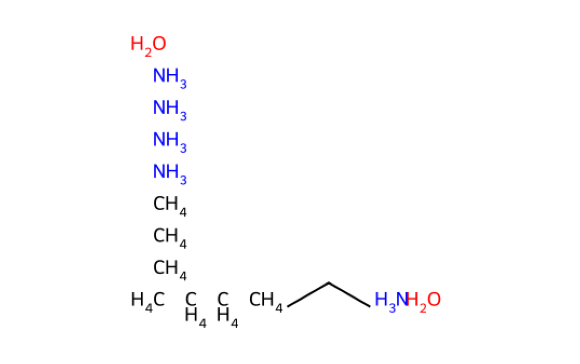

[graph 0] phase=1/4 beam_limit=2 fallback=0/3
[graph 0] phase=1/4 depth=1 beam=1 generated=402 feasible=318 retained=2 tried=402 best_score=0.2697 remaining_edges=15 step_time=2m 12.3s eta=33m 4.5s beam_limit=2


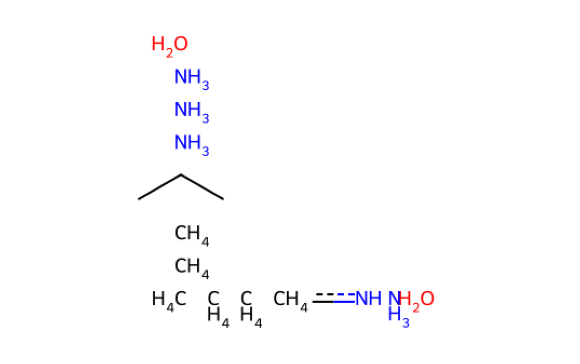

[graph 0] phase=1/4 depth=2 beam=2 generated=798 feasible=582 retained=2 tried=1200 best_score=0.7267 remaining_edges=14 step_time=2m 1.2s eta=28m 16.7s beam_limit=2


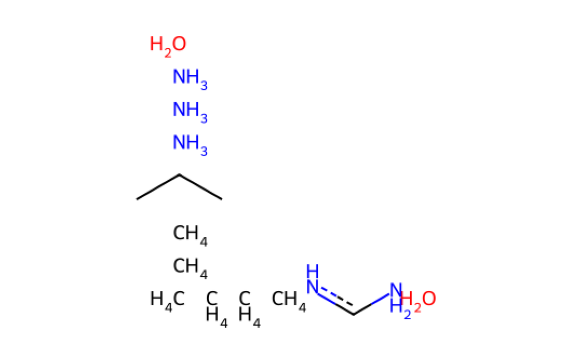

[graph 0] phase=1/4 depth=3 beam=2 generated=792 feasible=494 retained=2 tried=1992 best_score=0.7300 remaining_edges=13 step_time=1m 55.7s eta=25m 4.0s beam_limit=2


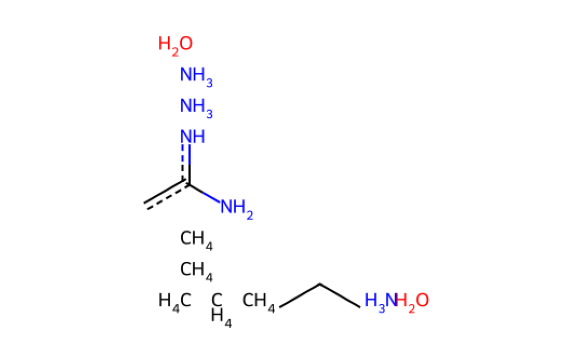

[graph 0] phase=1/4 depth=4 beam=2 generated=786 feasible=480 retained=2 tried=2778 best_score=0.7957 remaining_edges=12 step_time=2m 10.2s eta=26m 2.7s beam_limit=2


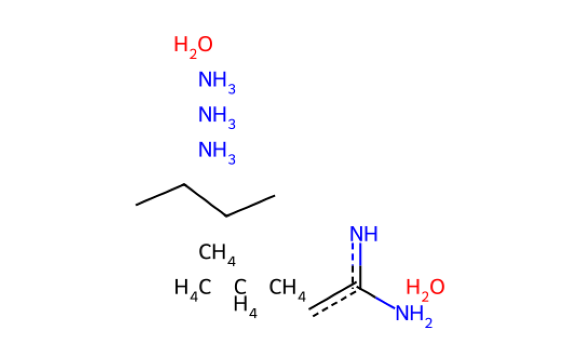

[graph 0] phase=1/4 depth=5 beam=2 generated=780 feasible=439 retained=2 tried=3558 best_score=0.8767 remaining_edges=11 step_time=1m 47.9s eta=19m 46.5s beam_limit=2


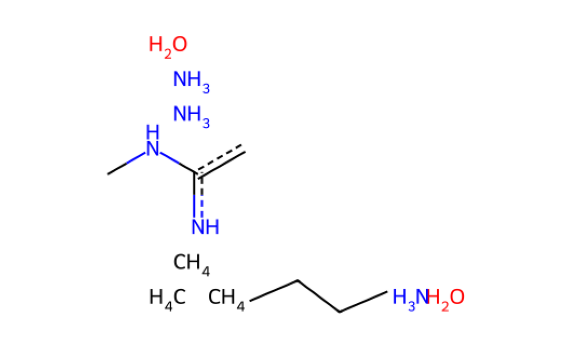

[graph 0] phase=1/4 depth=6 beam=2 generated=774 feasible=391 retained=2 tried=4332 best_score=0.7558 remaining_edges=10 step_time=1m 28.9s eta=14m 48.6s beam_limit=2


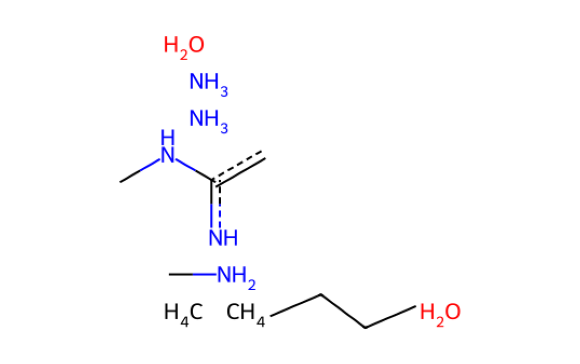

[graph 0] phase=1/4 depth=7 beam=2 generated=768 feasible=324 retained=2 tried=5100 best_score=0.6638 remaining_edges=9 step_time=1m 41.6s eta=15m 14.2s beam_limit=2


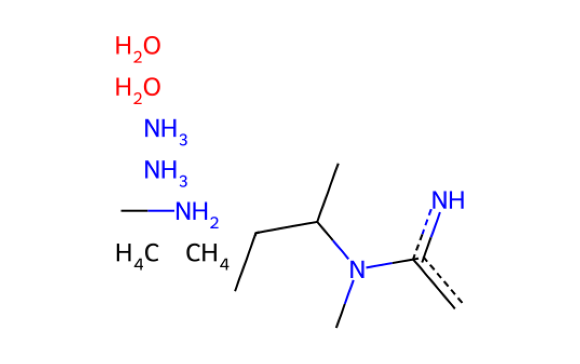

[graph 0] phase=1/4 depth=8 beam=2 generated=762 feasible=273 retained=2 tried=5862 best_score=0.7999 remaining_edges=8 step_time=1m 39.3s eta=13m 14.2s beam_limit=2


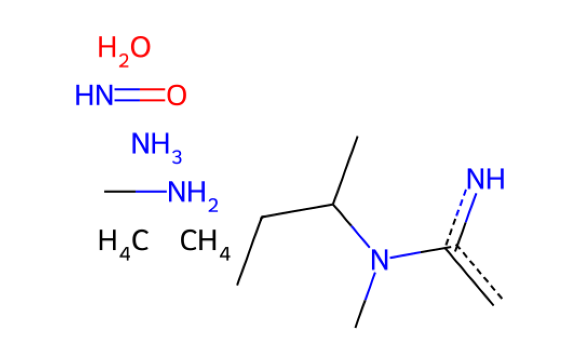

[graph 0] phase=1/4 depth=9 beam=2 generated=756 feasible=216 retained=2 tried=6618 best_score=0.8520 remaining_edges=7 step_time=1m 31.4s eta=10m 39.5s beam_limit=2


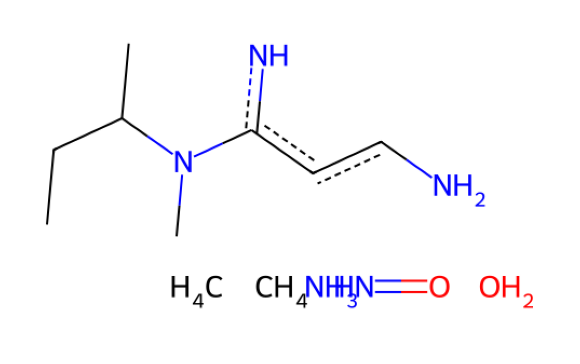

[graph 0] phase=1/4 depth=10 beam=2 generated=750 feasible=147 retained=2 tried=7368 best_score=0.7833 remaining_edges=6 step_time=1m 28.1s eta=8m 48.9s beam_limit=2


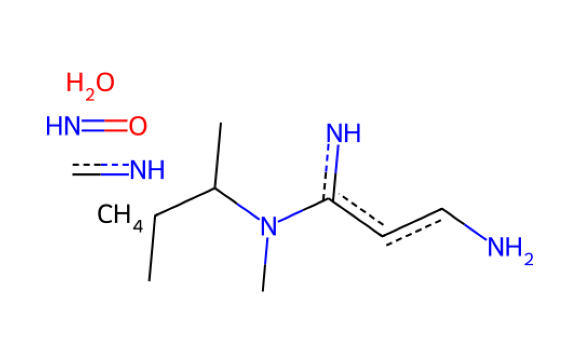

[graph 0] phase=1/4 depth=11 beam=2 generated=744 feasible=111 retained=2 tried=8112 best_score=0.8067 remaining_edges=5 step_time=1m 27.3s eta=7m 16.5s beam_limit=2


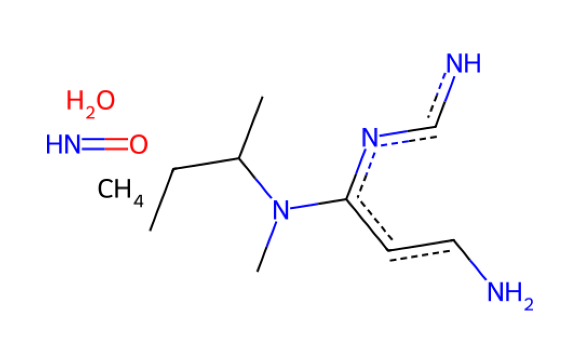

[graph 0] phase=1/4 depth=12 beam=2 generated=738 feasible=92 retained=2 tried=8850 best_score=0.8533 remaining_edges=4 step_time=1m 32.1s eta=6m 8.2s beam_limit=2


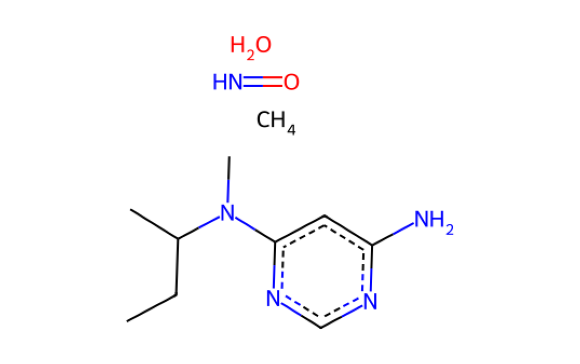

[graph 0] phase=1/4 depth=13 beam=2 generated=732 feasible=67 retained=2 tried=9582 best_score=0.8567 remaining_edges=3 step_time=1m 29.6s eta=4m 28.7s beam_limit=2


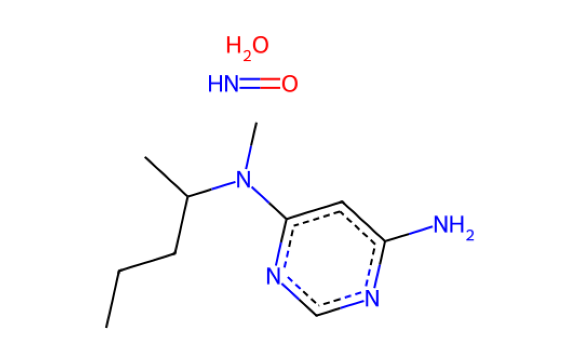

[graph 0] phase=1/4 depth=14 beam=2 generated=726 feasible=41 retained=2 tried=10308 best_score=0.8533 remaining_edges=2 step_time=1m 34.1s eta=3m 8.1s beam_limit=2


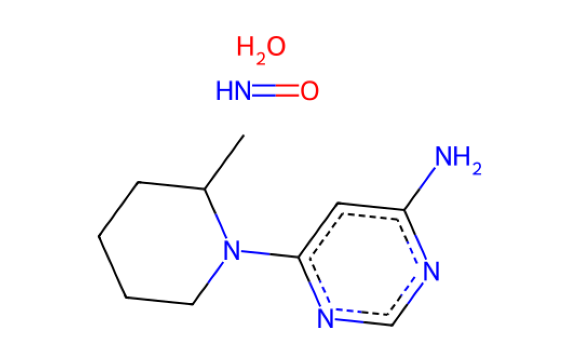

[graph 0] phase=1/4 depth=15 beam=2 generated=720 feasible=39 retained=2 tried=11028 best_score=0.9000 remaining_edges=1 step_time=1m 36.8s eta=1m 36.8s beam_limit=2


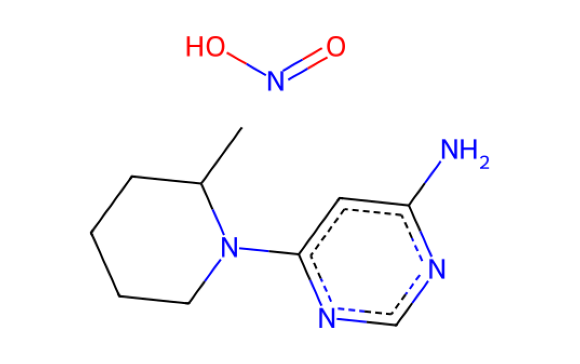

[graph 0] phase=1/4 depth=16 beam=2 generated=714 feasible=7 retained=2 tried=11742 best_score=0.9067 remaining_edges=0 step_time=1m 31.5s eta=0m 0.0s beam_limit=2


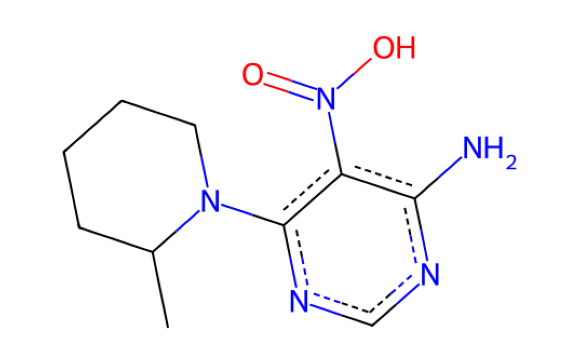

[graph 0] solved phase=1/4 depth=16 max_depth=16 edges=18 remaining_edges=0 tried=11742 elapsed=27m 9.0s eta=0m 0.0s
n_fit_graphs = 10
start_n_edges = 2
target_n_edges = 18
generation_path_length = 17


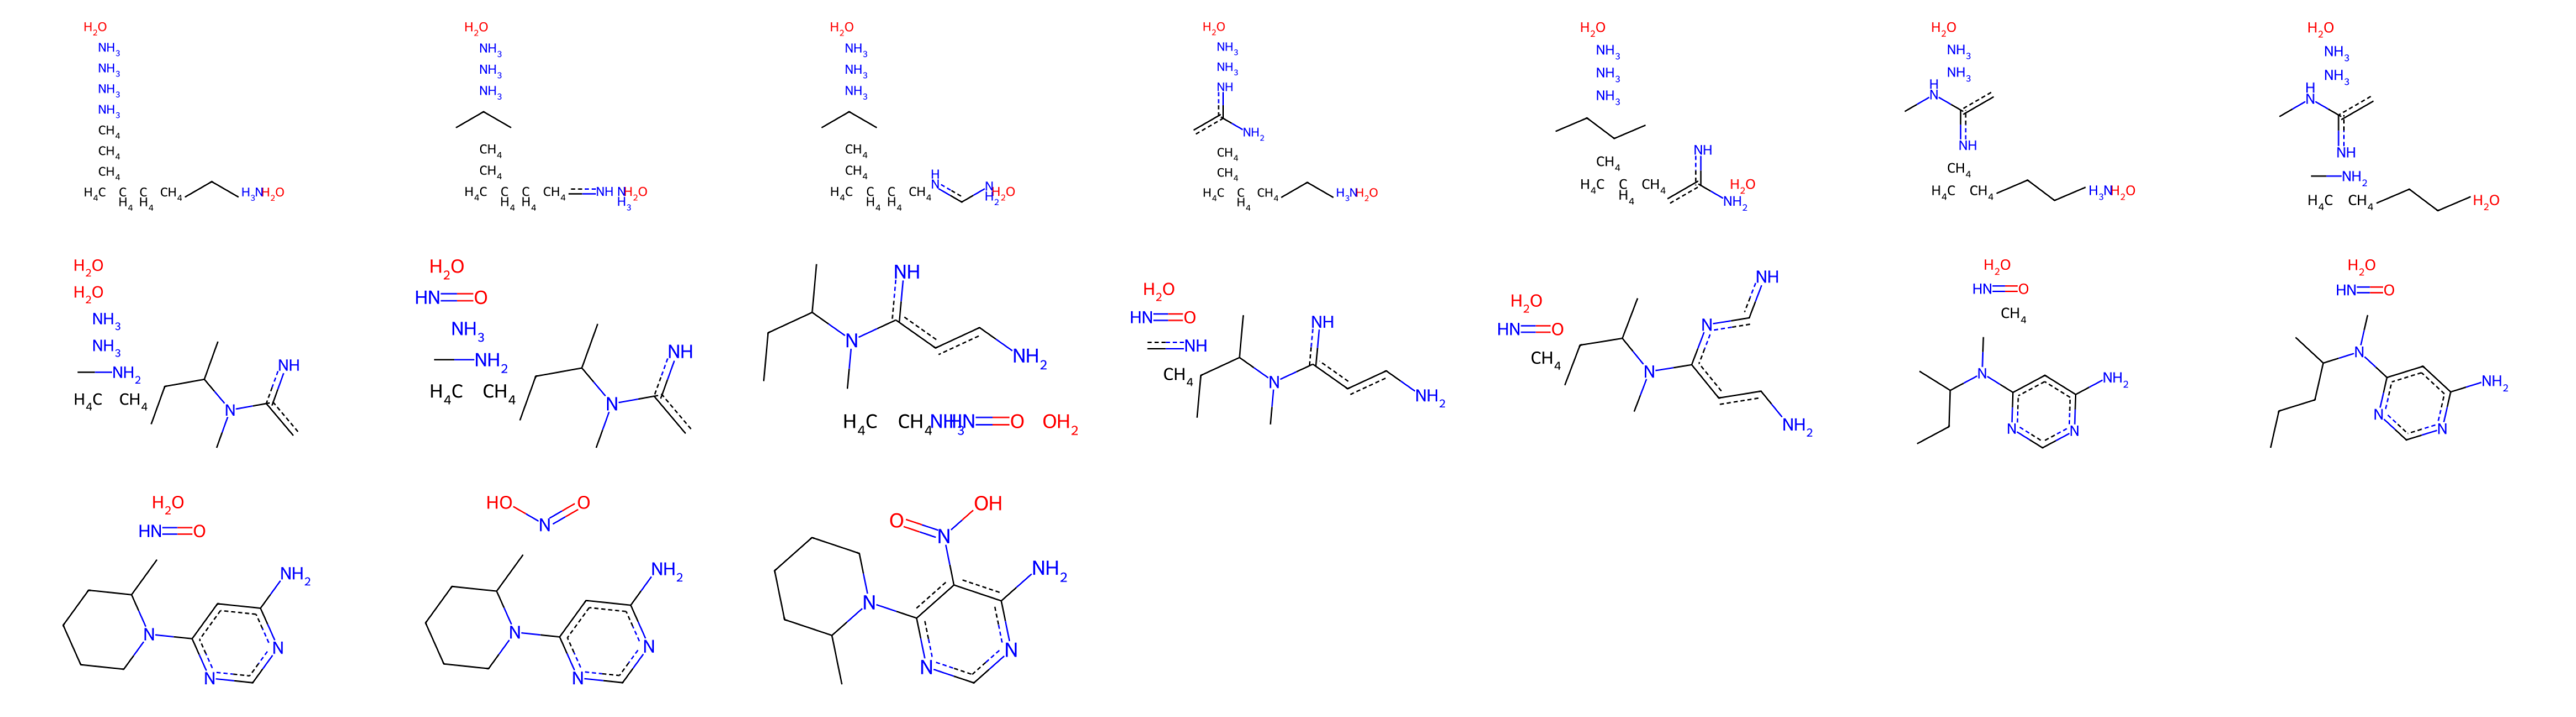

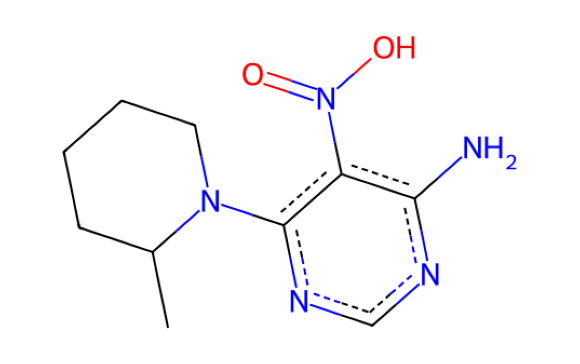

CPU times: user 1h 57min 50s, sys: 2min 43s, total: 2h 34s
Wall time: 48min 33s


In [ ]:
%%time
graph = random.choice(fit_graphs)
_ = display_graphs([graph], n_graphs_per_line=1)

start_graph, target_n_edges = remove_edges(graph, size=.9)
_ = display_graphs([start_graph], n_graphs_per_line=1)

generation_path = generator.generate(
    start_graph,
    n_edges=target_n_edges,
    draw_graphs_fn=lambda graphs: display_graphs(graphs, n_graphs_per_line=1),
)

print('n_fit_graphs =', len(fit_graphs))
print('start_n_edges =', start_graph.number_of_edges())
print('target_n_edges =', target_n_edges)
print('generation_path_length =', len(generation_path))
_ = display_graphs(generation_path, n_graphs_per_line=min(len(generation_path), 7))
_ = display_graphs([graph], n_graphs_per_line=1)


In [ ]:
from abstractgraph_generative.edge_generator import mix_connected_components
graph_a, graph_b = random.choice(fit_graphs), random.choice(fit_graphs)
start_graph_a, target_n_edges_a = remove_edges(graph_a, size=.9)
start_graph_b, target_n_edges_b = remove_edges(graph_b, size=.9)
mixed_graph = mix_connected_components(start_graph_a, start_graph_b, seed=0)
mixed_target_n_edges = int(np.mean([target_n_edges_a, target_n_edges_b]))
print(f'mixed_target_n_edges = {mixed_target_n_edges}')
_ = display_graphs([start_graph_a, start_graph_b, mixed_graph], n_graphs_per_line=3)

In [ ]:
generation_path = generator.generate(
    mixed_graph,
    n_edges=mixed_target_n_edges,
    draw_graphs_fn=lambda graphs: display_graphs(graphs, n_graphs_per_line=1),
)
_ = display_graphs([graph_a, graph_b, mixed_graph], n_graphs_per_line=2)

---